In [245]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE, simulate_for_sbi
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd

Dataset 1 Analysis

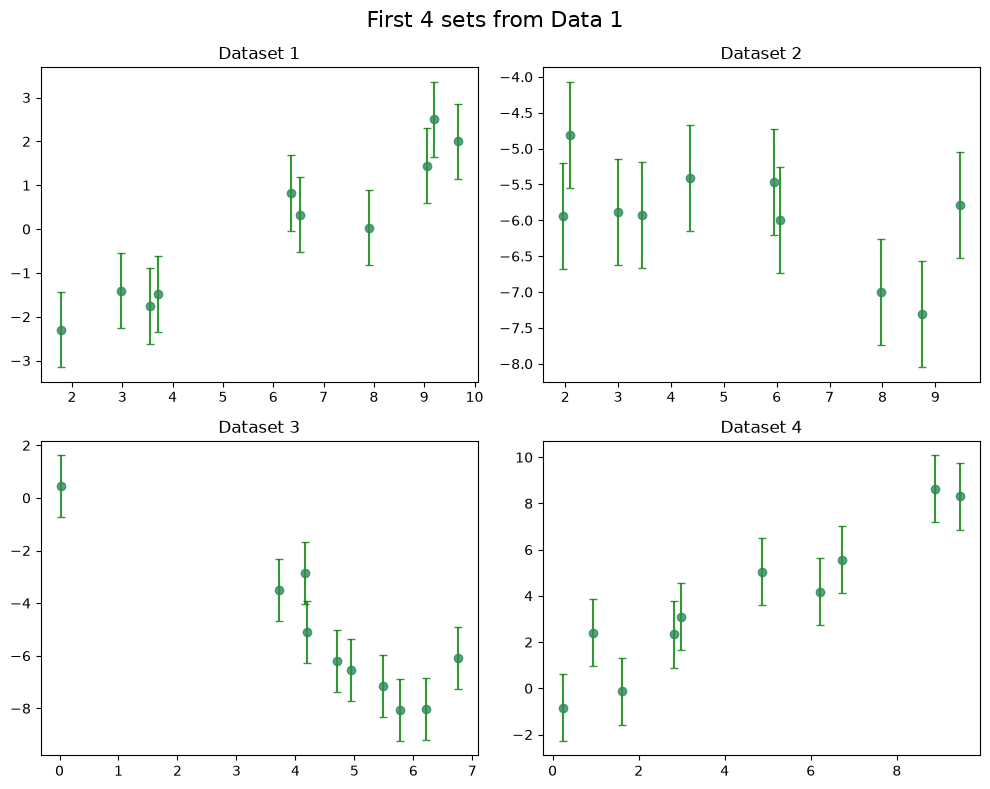

In [286]:
df = pd.read_csv('data1.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='seagreen',
                ecolor='green', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 1', fontsize=16)    
plt.tight_layout()
plt.show()


a = 0.5567794751136763, b = -3.361211144547272
a = -0.16019354928746876, b = -5.101979757390637
a ranges from -1.931 to 2.134
b ranges from -5.514 to 5.156


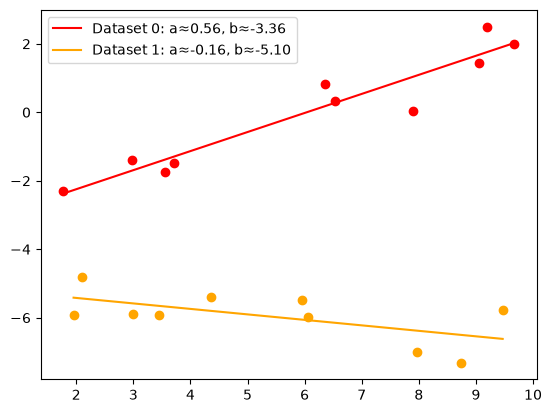

In [287]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

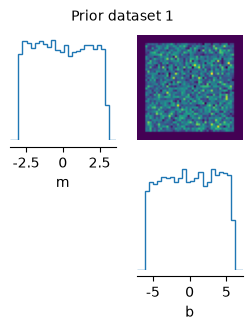

In [253]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-3, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples1 = prior_1.sample((10000,))


fig, ax = pairplot(
    prior_samples1,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 1", fontsize = 10 )
plt.show()

In [254]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, [sigma]])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].iloc[0]
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 121 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0  0.565006 0.106478 -3.446136 0.705882
       1 -0.172303 0.073200 -5.068105 0.418988
       2 -1.325351 0.216114  0.771639 1.103382
       3  0.922860 0.142501 -0.173974 0.780536
       4  1.561851 0.077371  1.072134 0.465497
       5  0.327082 0.182553  1.460389 1.048679
       6 -0.809274 0.184056 -4.020277 0.820381
       7  1.897340 0.039192 -4.639433 0.212401
       8 -0.740944 0.077693  1.690467 0.435869
       9 -0.391621 0.054772 -2.340427 0.275488
      10 -0.604716 0.079227  2.511749 0.438385
      11 -0.101836 0.066804  5.117067 0.397219
      12  1.473482 0.190566  2.892506 1.295125
      13 -0.231604 0.042251 -0.737270 0.191933
      14  1.539978 0.101660 -2.283453 0.753531
      15 -1.715995 0.158073 -1.519686 0.907517
      16 -0.484487 0.073564  3.939586 0.342295
      17 -1.159969 0.069136  1.106967 0.331447
      18  1.241068 0.064371  1.228641 0.359222
      19  0.992959 0.067000 -3.057887 0.394715
      20 -0.4

  0%|          | 0/5000 [00:00<?, ?it/s]

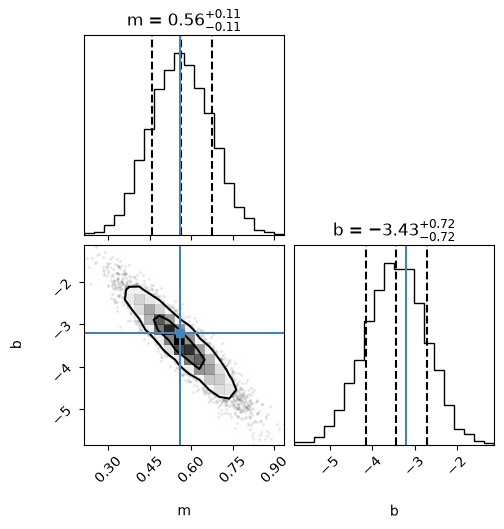

In [ ]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, [sigma]]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv

truth_file = pd.read_csv('truth.csv')
row = truth_file[truth_file['dataset'] == ds_id].iloc[0]
truths = [row['b'], row['a']]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

Dataset 2 Analysis

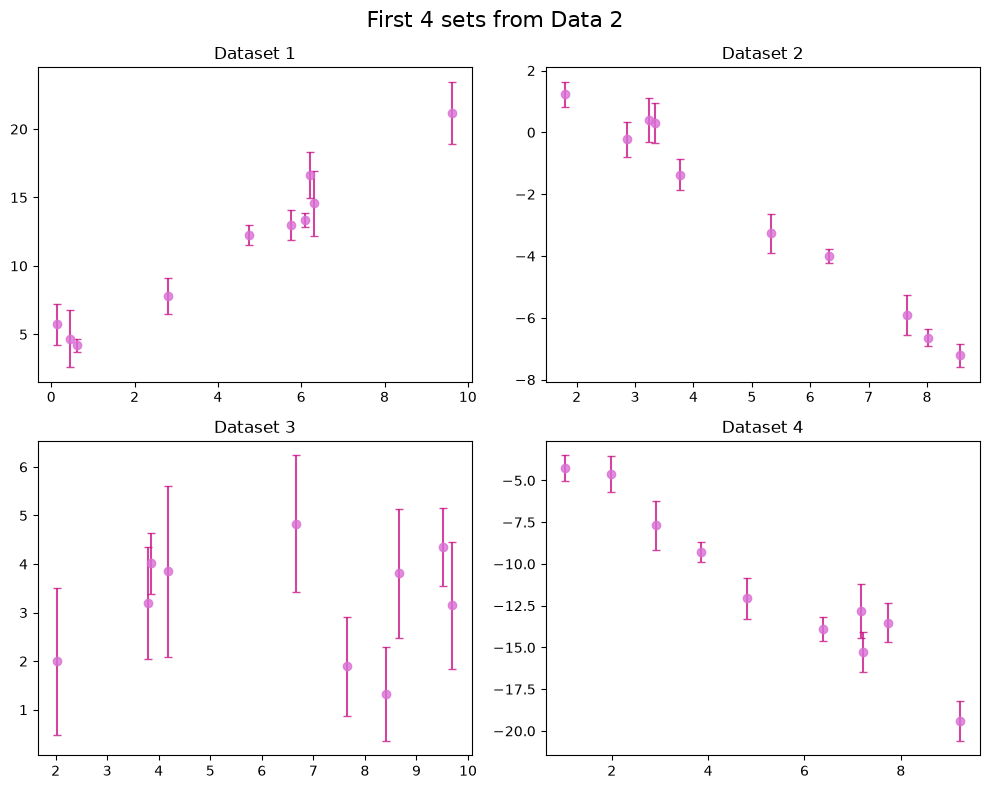

In [288]:
df = pd.read_csv('data2.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='orchid',
                ecolor='mediumvioletred', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 2', fontsize=16)    
plt.tight_layout()
plt.show()

a = 1.7458161902051454, b = 3.8832076996103444
a = -1.2948889985058631, b = 3.926804669969544
a ranges from -2.136 to 2.012
b ranges from -5.918 to 4.918


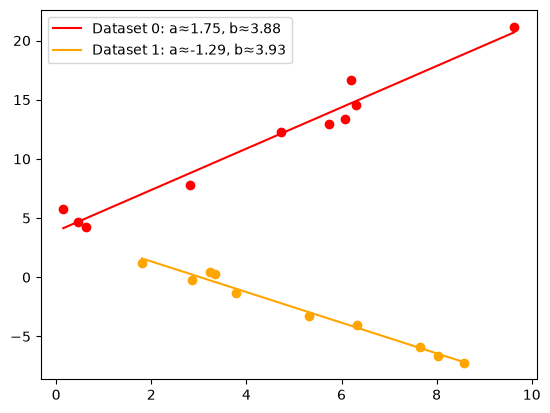

In [289]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

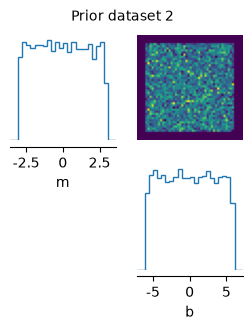

In [ ]:
#Creating a prior for the set based on that range

prior_2 = BoxUniform(low=torch.tensor([-3, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples2 = prior_2.sample((10000,))


fig, ax = pairplot(
    prior_samples2,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 2", fontsize = 10 )
plt.show()

In [270]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 200 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0  1.746337 0.125329  3.438063 0.519194
       1 -1.286772 0.063070  3.752219 0.382644
       2 -0.083552 0.131502  3.803927 0.894755
       3 -1.673998 0.127668 -2.587461 0.664824
       4 -0.910040 0.101513 -1.930591 0.676779
       5 -0.016325 0.155242  3.583704 0.589547
       6 -1.417259 0.202077 -2.781167 1.324917
       7 -0.797375 0.069875 -2.227201 0.406163
       8 -1.332942 0.129788  0.102584 0.681197
       9  1.995690 0.094463  0.866498 0.449937
      10  0.515790 0.084701 -4.046826 0.396096
      11  0.438949 0.049184  1.246994 0.375377
      12  1.242213 0.041663 -3.271538 0.222773
      13  1.851617 0.069608 -0.864905 0.389016
      14 -0.860982 0.097655  3.770765 0.431722
      15 -0.781061 0.198793 -3.111947 1.168954
      16 -0.152735 0.196702  3.404233 0.562982
      17 -0.471938 0.165157 -2.891758 0.604875
      18  1.293428 0.061973 -2.809562 0.438778
      19  1.798966 0.130652  1.355720 0.832225
      20  0.1

  0%|          | 0/5000 [00:00<?, ?it/s]

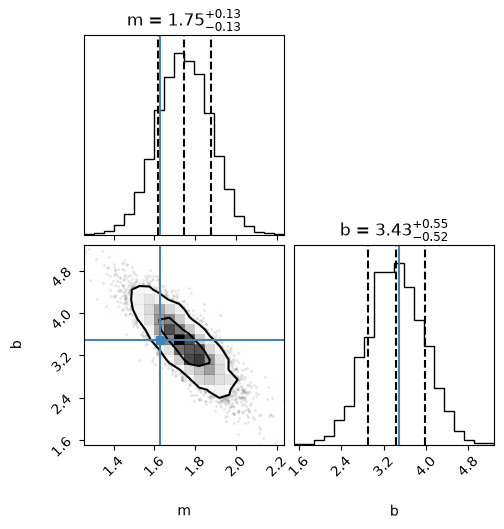

In [276]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [1.629722,3.493063]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



Dataset 3 Analysis

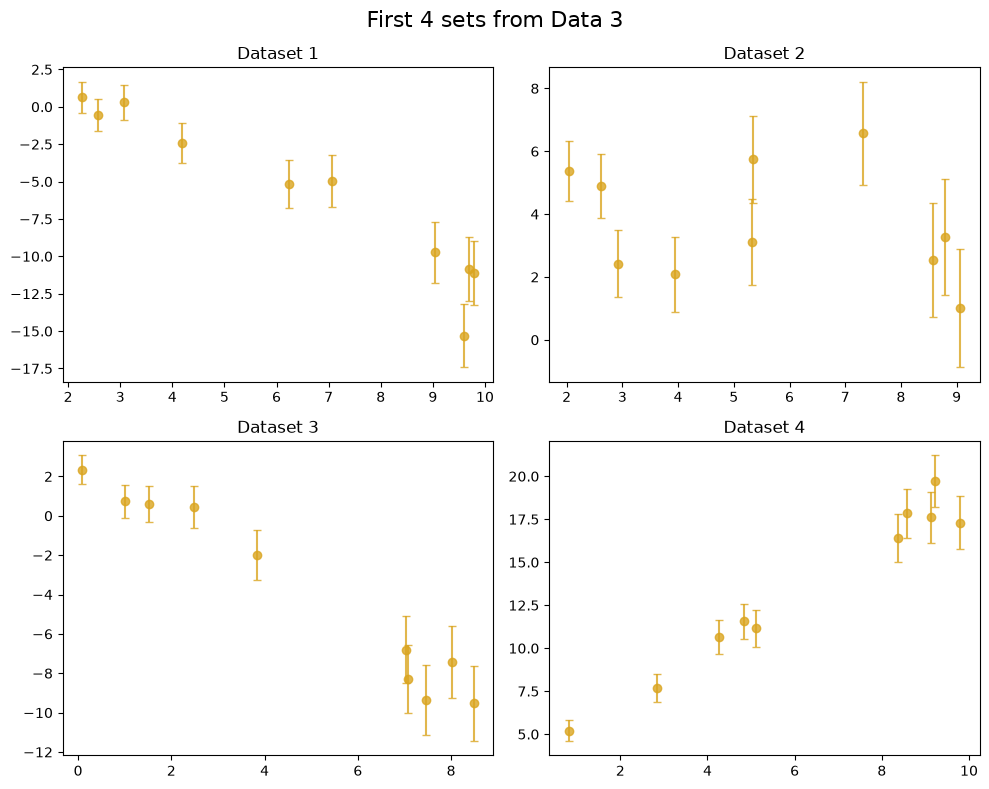

In [292]:
df = pd.read_csv('data3.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='goldenrod',
                ecolor='goldenrod', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 3', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.7072390028297482, b = 4.92599730988589
a = -0.1969695584637027, b = 4.806833987309417
a ranges from -1.977 to 2.213
b ranges from -5.324 to 5.409


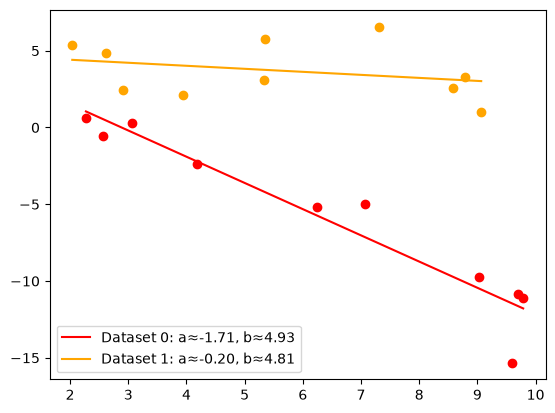

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')


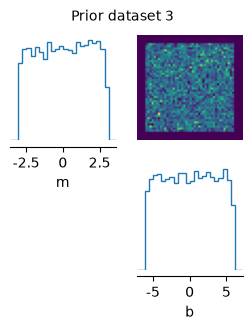

In [ ]:
#Creating a prior for the set based on that range

prior_3 = BoxUniform(low=torch.tensor([-3, -6]), 
                      high=torch.tensor([3, 6]))

prior_samples3 = prior_3.sample((10000,))

fig, ax = pairplot(
    prior_samples3,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 3", fontsize = 10 )
plt.show()

In [298]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 85 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.596807 0.061155 -2.367327 0.267869
       1  0.885861 0.178849  0.376038 0.980404
       2  0.545717 0.113089 -2.158804 0.679126
       3 -0.023022 0.139758  0.143976 0.698002
       4 -1.396606 0.095527  4.683785 0.303246
       5 -0.429628 0.154188  0.821674 0.903101
       6  0.858003 0.132853  1.844052 0.592920
       7  1.073170 0.113072  5.161088 0.412566
       8  0.622292 0.135109  2.083269 0.677540
       9  2.050894 0.129589 -2.655469 0.562109
      10  0.343999 0.186699  3.518305 0.663317
      11  0.714846 0.216710  1.319240 0.992866
      12 -0.651510 0.063852 -3.232238 0.355139
      13  0.505755 0.152096  1.238867 0.559367
      14  0.477850 0.099108 -2.075693 0.545251
      15  1.079110 0.099236 -5.500115 0.335533
      16 -0.375203 0.095699  5.454135 0.437058
      17  0.821035 0.086127  3.703532 0.467962
      18 -0.965063 0.039491  2.275881 0.194949
      19  1.167776 0.153953 -3.430404 0.445507
      20 -1.7

  0%|          | 0/5000 [00:00<?, ?it/s]

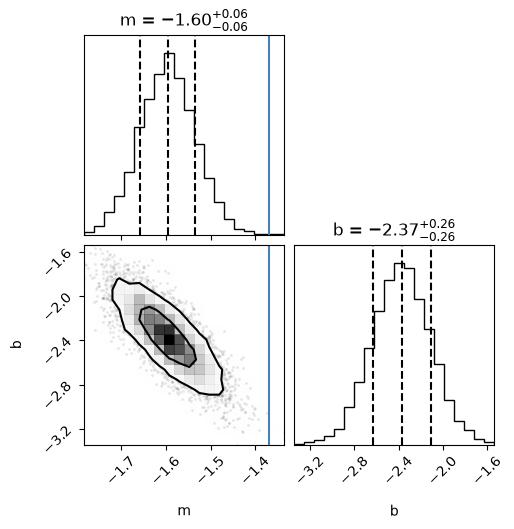

In [301]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [-1.369837, 3.519913]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

Dataset 4 Analysis

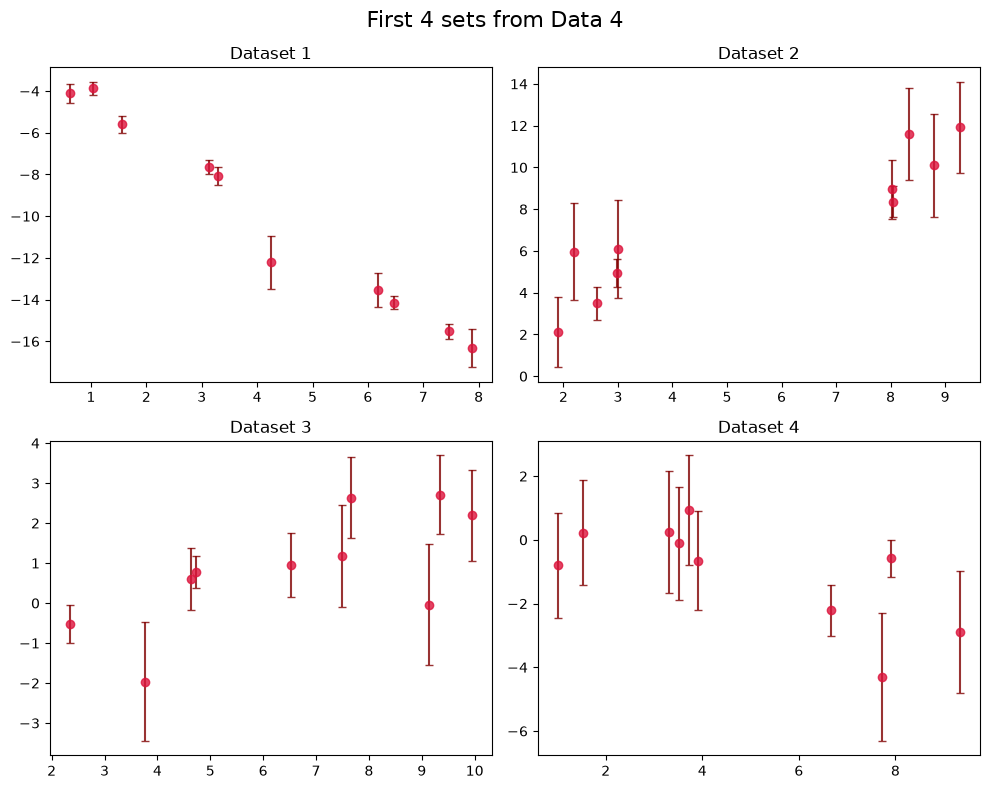

In [303]:
df = pd.read_csv('data4.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='crimson',
                ecolor='maroon', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 4', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.7546111169041498, b = -2.7556310282883936
a = 0.9775245441766431, b = 1.9674261850263983
a ranges from -2.469 to 2.265
b ranges from -6.864 to 6.246


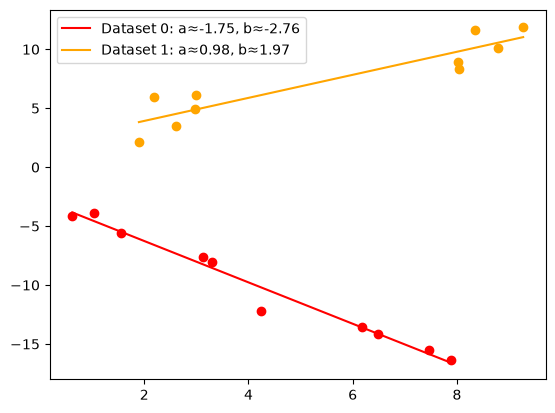

In [304]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

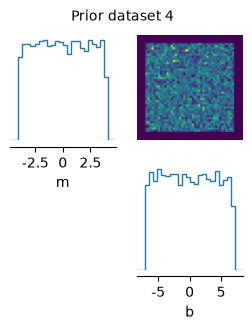

In [308]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_4 = BoxUniform(low=torch.tensor([-4, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples4 = prior_4.sample((10000,))


fig, ax = pairplot(
    prior_samples4,
    labels=["m", "b"],
    figsize=(3,3)
)
plt.suptitle("Prior dataset 4", fontsize = 10 )
plt.show()

In [309]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise

    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000  
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 240 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.773215 0.062188 -2.512239 0.243622
       1  1.076206 0.170142  1.009727 0.829984
       2  0.397478 0.108239 -1.421945 0.648795
       3 -0.229154 0.165604  0.154143 1.051111
       4 -1.544181 0.053809  4.403039 0.322398
       5 -0.363866 0.217505 -1.778323 1.857157
       6  0.729102 0.159210  2.875140 0.862304
       7  1.252190 0.103486  4.553399 0.448425
       8  0.333942 0.148770  3.758777 0.779664
       9  2.282444 0.108156 -3.515441 0.449925
      10  0.663493 0.255256  3.657973 0.892350
      11  0.868322 0.097178  1.205870 0.532339
      12 -0.753860 0.056400 -3.232745 0.399180
      13  0.552523 0.126145  2.332038 0.777944
      14  0.254400 0.099563 -2.874405 0.742958
      15  0.857946 0.073756 -4.826092 0.474361
      16 -0.249157 0.129910  4.372236 0.718402
      17  0.960025 0.124727  2.941929 0.683587
      18 -1.054344 0.038547  2.730299 0.210051
      19  1.325999 0.122825 -3.969875 0.352678
      20 -1.6

  0%|          | 0/5000 [00:00<?, ?it/s]

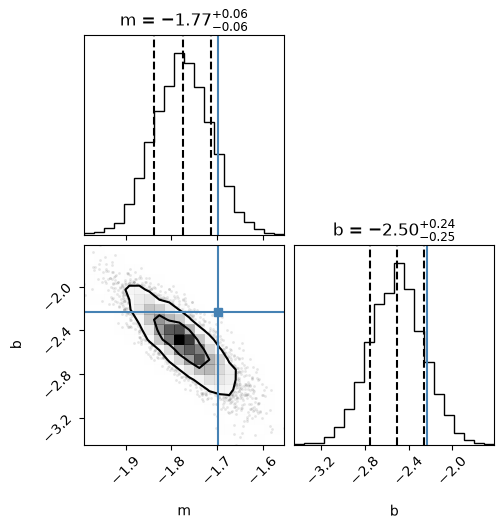

In [310]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

#compare to true values from that csv
truths = [-1.696825,-2.232021]
labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=truths, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)